In [73]:
## Import libraries for data manipulation, numerical analysis, visualization, and statistical testing 


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [74]:
## Load the customer churn dataset into a Pandas DataFrame

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [75]:
## Check the number of customers and attributes in the dataset

df.shape

(7043, 21)

In [76]:
## Preview the first five records to understand the structure and values of the dataset

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [77]:
# Display all column names to understand the available customer attributes

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [78]:
# Inspect data types, non-null counts, and overall dataset structure

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [79]:
# Check whether the dataset contains duplicate customer records

df.duplicated().sum()

np.int64(0)

In [116]:
# Check the least frequent TotalCharges values
df["TotalCharges"].value_counts().tail(10)

TotalCharges
2625.25    1
6886.25    1
1495.10    1
743.30     1
1419.40    1
1990.50    1
7362.90    1
346.45     1
306.60     1
6844.50    1
Name: count, dtype: int64

In [81]:
# Inspect TotalCharges values to identify unusual or potentially invalid entries

df["TotalCharges"].value_counts().tail(10)

TotalCharges
2625.25    1
6886.25    1
1495.1     1
743.3      1
1419.4     1
1990.5     1
7362.9     1
346.45     1
306.6      1
6844.5     1
Name: count, dtype: int64

In [82]:
# Convert TotalCharges from text to numeric values and treat invalid entries as missing values

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [83]:
# Check how many missing values were created after converting TotalCharges to numeric

df["TotalCharges"].isna().sum()

np.int64(11)

In [84]:
# Examine the customer records where TotalCharges is missing

df[df["TotalCharges"].isna()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [85]:
# Replace missing TotalCharges values with zero because these customers have zero months of tenure

df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [86]:
# Verify that TotalCharges no longer contains missing values

df["TotalCharges"].isna().sum()

np.int64(0)

In [87]:
# Confirm that TotalCharges is now stored as a numeric column

df["TotalCharges"].dtype

dtype('float64')

In [88]:
# Check for missing values across all columns after data cleaning

df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [89]:
# Inspect unique values in categorical columns to identify categories and possible inconsistencies

for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}:")
    print(df[col].unique())


customerID:
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines:
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService:
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup:
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection:
<StringArray>
['No', 'Yes', 'No internet 

/var/folders/cs/bx35qn657bjb2sh3bhnt2kgc0000gn/T/ipykernel_10314/625811045.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [90]:
# Check categorical columns for values containing only whitespace

for col in df.select_dtypes(include="object").columns:
    spaces = df[col].astype(str).str.contains(r"^\s|\s$", regex=True).sum()
    if spaces > 0:
        print(col, spaces)

/var/folders/cs/bx35qn657bjb2sh3bhnt2kgc0000gn/T/ipykernel_10314/2267711650.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [91]:
#EDA 

df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [92]:
#churn rate.
churn_rate = (df["Churn"] == "Yes").mean() * 100
churn_rate

np.float64(26.536987079369588)

In [93]:
#Calculate retention rate

retention_rate = (df["Churn"] == "No").mean() * 100
retention_rate

np.float64(73.4630129206304)

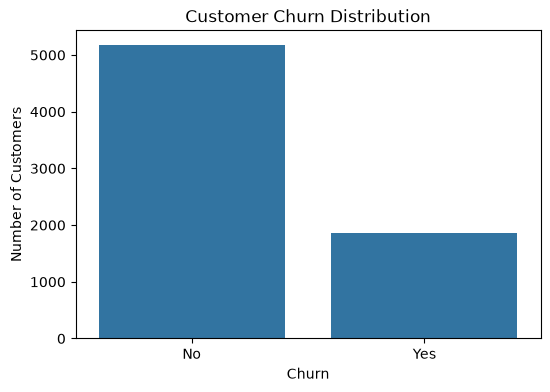

In [117]:
# Create a figure with a width of 6 inches and height of 4 inches
plt.figure(figsize=(6, 4))

# Create a count plot to show the number of customers in each churn category
sns.countplot(data=df, x="Churn")

# Add a title to the chart
plt.title("Customer Churn Distribution")

# Label the X-axis
plt.xlabel("Churn")

# Label the Y-axis
plt.ylabel("Number of Customers")

# Display the chart
plt.show()

In [95]:
#Are customers on certain contract types more likely to leave?

# 1) Calculate churn rate by contract
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


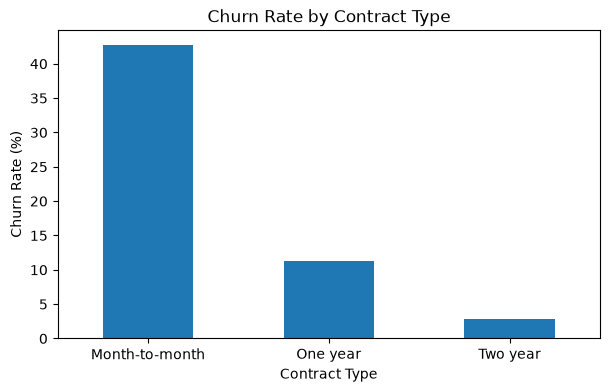

In [96]:
#create a chart specifically showing the churn percentage

contract_churn["Yes"].plot(kind="bar", figsize=(7, 4))

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.savefig("../output/figures/churn_rate_by_contract.png", dpi=300, bbox_inches="tight")

plt.show()



In [118]:
# 2) Does tenure affect churn?

# Compare the tenure of customers who churned vs. customers who stayed
df.groupby("Churn")["tenure"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
Churn,,,,
No,37.569965,38.0,0,72
Yes,17.979133,10.0,1,72


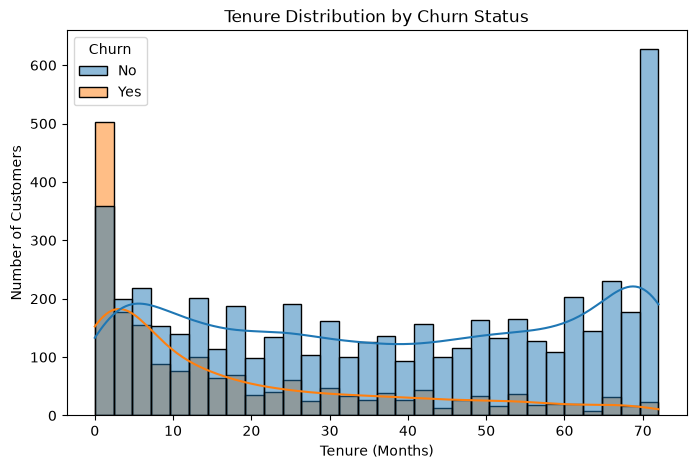

In [98]:
#Visualize tenure

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

In [99]:
#Does Monthly Charge affect churn?

df.groupby("Churn")["MonthlyCharges"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
Churn,,,,
No,61.265124,64.425,18.25,118.75
Yes,74.441332,79.650,18.85,118.35


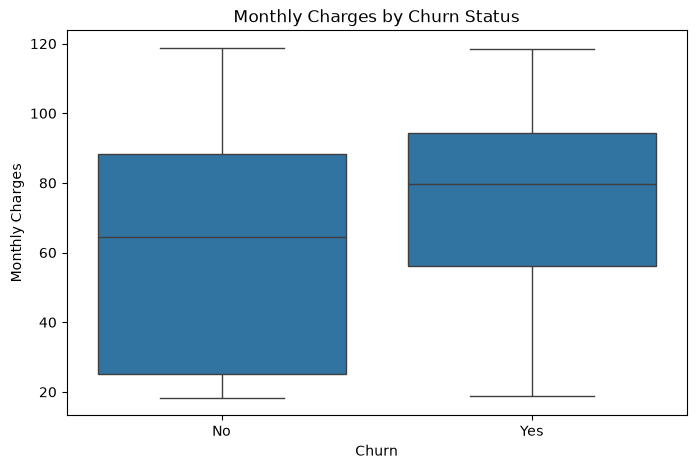

In [100]:
#VISUALISE MONTHLY CHARGE

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [101]:
#Does the type of internet service a customer uses relate to churn?

internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


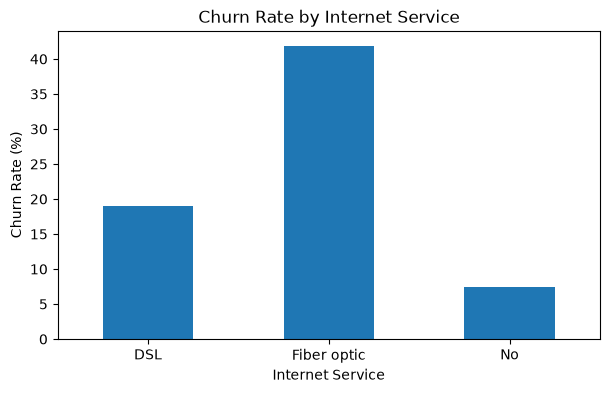

In [119]:
# Visualize churn rate by internet service type
internet_churn["Yes"].plot(kind="bar", figsize=(7, 4))

# Add chart title
plt.title("Churn Rate by Internet Service")

# Label the X-axis
plt.xlabel("Internet Service")

# Label the Y-axis
plt.ylabel("Churn Rate (%)")

# Keep category labels horizontal
plt.xticks(rotation=0)

# Display the chart
plt.show()

In [103]:
#Does Tech Support relate to churn?

techsupport_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

techsupport_churn

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


In [104]:


#Payment Method

payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn

#So customers using electronic check are much more likely to churn than customers using automatic payment methods.

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


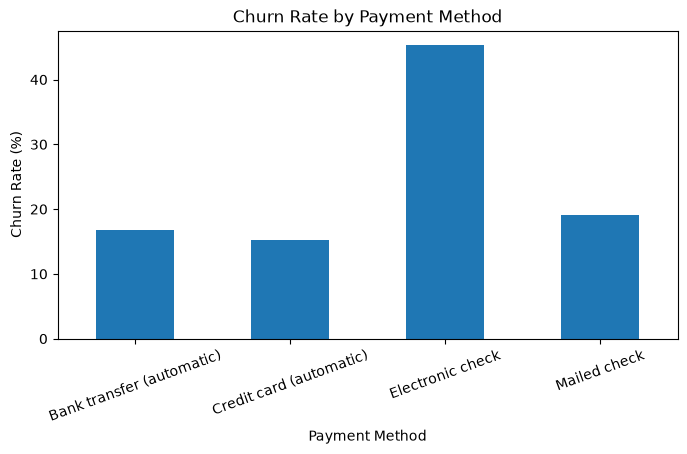

In [120]:
# Visualize churn rate by payment method
payment_churn["Yes"].plot(kind="bar", figsize=(8, 4))

# Add chart title
plt.title("Churn Rate by Payment Method")

# Label the X-axis
plt.xlabel("Payment Method")

# Label the Y-axis
plt.ylabel("Churn Rate (%)")

# Rotate labels slightly for better readability
plt.xticks(rotation=20)

# Save the chart as a high-resolution PNG file
plt.savefig(
    "../output/figures/churn_rate_by_payment_method.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the chart
plt.show()

In [106]:
# Statistical test: Check whether Contract Type and Churn are related

# Create a contingency table showing Contract Type vs Churn
contract_table = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

# Perform a Chi-square test of independence
# This checks whether the difference in churn across contract types
# is statistically significant
chi2, p_value, dof, expected = stats.chi2_contingency(contract_table)

# Display the test results
print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 1184.5965720837926
p-value: 5.863038300673393e-258


In [107]:
# Statistical test: Check whether Payment Method and Churn are related

# Create a contingency table showing Payment Method vs Churn
payment_table = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"]
)

# Perform Chi-square test
chi2, p_value, dof, expected = stats.chi2_contingency(payment_table)

# Display the test results
print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 648.1423274814
p-value: 3.6823546520098007e-140


In [108]:
# Statistical test: Check whether Monthly Charges differ between churned and retained customers

# Select monthly charges for customers who churned
churned_charges = df[df["Churn"] == "Yes"]["MonthlyCharges"]

# Select monthly charges for customers who stayed
not_churned_charges = df[df["Churn"] == "No"]["MonthlyCharges"]

# Perform an independent two-sample t-test
# equal_var=False is used because the two groups may have different variances
t_stat, p_value = stats.ttest_ind(
    churned_charges,
    not_churned_charges,
    equal_var=False
)

# Display the test results
print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 18.407526676414673
p-value: 8.592449331547065e-73


 KPI ANALYSIS

Now we're going to calculate the business-level numbers a company would actually care about:

Overall churn rate
Retention rate
Average monthly charge
Average tenure
Revenue associated with churn
Potentially revenue at risk 

In [109]:
# KPI: Average monthly charge per customer

# Calculate the average monthly amount paid by customers
avg_monthly_charge = df["MonthlyCharges"].mean()

# Display the KPI
print("Average Monthly Charge: $", round(avg_monthly_charge, 2))

Average Monthly Charge: $ 64.76


In [110]:
# Retention rate

retention_rate = 100 - churn_rate

print("Retention Rate:", round(retention_rate, 2), "%")

Retention Rate: 73.46 %


In [111]:
# Average monthly charge

avg_monthly_charge = df["MonthlyCharges"].mean()

print("Average Monthly Charge:", round(avg_monthly_charge, 2))

Average Monthly Charge: 64.76


In [112]:
# Average customer tenure

avg_tenure = df["tenure"].mean()

print("Average Customer Tenure:", round(avg_tenure, 2), "months")

Average Customer Tenure: 32.37 months


In [113]:
# KPI: Total revenue associated with churned customers

# Select customers who have churned
churned_revenue = df[df["Churn"] == "Yes"]["TotalCharges"]

# Add their total charges
churned_revenue = churned_revenue.sum()

# Display the KPI
print("Revenue Associated with Churn: $", round(churned_revenue, 2))

Revenue Associated with Churn: $ 2862926.9


In [114]:
# Potential revenue at risk

revenue_at_risk = df[df["Churn"] == "Yes"]["MonthlyCharges"].sum()

print("Potential Monthly Revenue at Risk: $", round(revenue_at_risk, 2))

Potential Monthly Revenue at Risk: $ 139130.85


# Business Insights & Recommendations

Based on the EDA, statistical testing, and KPI analysis, the key findings are:

In [115]:
# Churn rate by contract type

contract_churn_rate = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

contract_churn_rate

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

# Key Business Insights

| Finding | Evidence | Business Implication |
|---|---|---|
| Month-to-month customers have the highest churn | 42.71% churn vs 11.27% for one-year and 2.83% for two-year contracts | Encourage customers to move toward longer-term contracts |
| Churn is concentrated among newer customers | Median tenure is 10 months for churned customers vs 38 months for retained customers | Focus retention efforts on customers during their first year |
| Fiber optic customers have higher churn | 41.89% churn vs 18.96% for DSL customers | Investigate pricing, service quality, and customer experience |
| Electronic check users have the highest churn | 45.29% churn rate | Investigate payment experience and encourage alternative payment methods |
| Churned customers have higher monthly charges | Median monthly charge of $79.65 vs $64.43 for retained customers | Prioritize higher-value customers in retention campaigns |
| Contract type is statistically associated with churn | Chi-square test p-value < 0.05 | Contract structure is a significant factor associated with churn |
| Payment method is statistically associated with churn | Chi-square test p-value < 0.05 | Payment method should be considered when designing retention strategies |
| Monthly charges differ significantly by churn status | t-test p-value < 0.05 | Pricing/customer value should be considered in churn analysis |

# Business Recommendations

### 1. Reduce month-to-month churn
Target month-to-month customers with retention offers and incentives to move toward one-year or two-year contracts.

### 2. Strengthen early customer retention
Focus onboarding and proactive support on customers during their first year, when churn risk is higher.

### 3. Investigate fiber optic churn
Analyze pricing, service quality, and customer experience for fiber optic customers to understand their higher churn rate.

### 4. Improve payment experience
Investigate the high churn associated with electronic check payments and encourage customers to adopt alternative payment methods.

### 5. Prioritize high-value customers
Customers with higher monthly charges represent greater potential revenue impact, so retention campaigns can prioritize these segments.

### 6. Monitor retention KPIs
Regularly track churn rate, retention rate, contract mix, tenure, and monthly charges to identify emerging churn patterns.